In [18]:
import pandas as pd
df=pd.read_csv("WineQT.csv")

In [19]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [20]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


Observations intéressantes :

aucun valeur monquante

Quality (variable cible) : varie de 3 à 8, avec une moyenne de 5.66, ce qui suggère que la plupart des vins sont de qualité moyenne

Total sulfur dioxide : très variable (6 à 289), avec un écart-type important (32.78), indiquant une forte dispersion.

Residual sugar : également très dispersé (0.9 à 15.5), certains vins sont très secs, d'autres plus sucrés.

Density : très stable autour de 0.996, avec très peu de variation (std = 0.002), ce qui est normal pour le vin.

pH : relativement stable (2.74 à 4.01), centré autour de 3.31, ce qui confirme l'acidité typique du vin.

Alcohol : varie de 8.4% à 14.9%, avec une moyenne de 10.44%.



Identifier les problèmes  :
la suppression du colonne Id car inutile dans notre cas

In [21]:
# Suppression définitive de la colonne Id
df = df.drop(columns=['Id'])


In [22]:
print(df.columns)


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [23]:

duplicates = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {duplicates}")

Nombre de lignes dupliquées : 125


je veux tester les 2  approches cad sans traiter les outliers                     
          Approche 1 : Baseline
          Approche 2 : Traitement des outliers  et  Feature Engineering   

Approche 1 : Baseline                           tester des modèles qui ne sont pas sensibles aux outliers 

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# ============================================================================ #
# 1️⃣ LOAD DATA
# ============================================================================ #
df = pd.read_csv("WineQT.csv")

# Binary target : 0 = Mauvais/Moyen (≤6), 1 = Bon (>6)
df['quality_bin'] = (df['quality'] > 5).astype(int)

X = df.drop(columns=['quality', 'quality_bin'])
y = df['quality_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"✅ Train={X_train.shape[0]} | Test={X_test.shape[0]}")
print(f"📊 Distribution Train:\n{y_train.value_counts(normalize=True)}")

# ============================================================================ #
# 2️⃣ MODELS (anti-overfitting)
# ============================================================================ #
models = {
    'RandomForest': Pipeline([
        ('scaler', RobustScaler()),
        ('model', RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features='sqrt',
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    'XGBoost': Pipeline([
        ('scaler', RobustScaler()),
        ('model', XGBClassifier(
            n_estimators=50,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.7,
            colsample_bytree=0.7,
            scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
            random_state=42,
            eval_metric='logloss'
        ))
    ]),
    
    'LightGBM': Pipeline([
        ('scaler', RobustScaler()),
        ('model', LGBMClassifier(
            n_estimators=50,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_samples=20,
            class_weight='balanced',
            random_state=42,
            verbose=-1
        ))
    ]),
    
    'GradientBoosting': Pipeline([
        ('scaler', RobustScaler()),
        ('model', GradientBoostingClassifier(
            n_estimators=50,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.7,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42
        ))
    ])
}

# ============================================================================ #
# 3️⃣ TRAIN + EVALUATE (F1-macro)
# ============================================================================ #
results = {}

for name, model in models.items():
    print(f"\n🔹 {name}...")

    # Cross-validation F1-macro
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # F1-macro
    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_cv    = cv_scores.mean()
    f1_test  = f1_score(y_test, y_test_pred, average='macro')

    overfit = f1_train - f1_test

    results[name] = {
        'Train_F1': f1_train,
        'CV_F1': f1_cv,
        'Test_F1': f1_test,
        'Overfitting': overfit
    }

    status = "✅" if abs(overfit) < 0.05 else "⚠️ Overfitting"
    print(f"Train F1 : {f1_train:.4f} | CV F1 : {f1_cv:.4f} | Test F1 : {f1_test:.4f} | Overfit : {overfit:.4f} {status}")

# ============================================================================ #
# 4️⃣ FINAL RESULTS
# ============================================================================ #
results_df = pd.DataFrame(results).T.sort_values('Test_F1', ascending=False)
print("\n🏆 FINAL RANKING (Binary Classification - F1-macro)")
print(results_df)


✅ Train=914 | Test=229
📊 Distribution Train:
quality_bin
1    0.543764
0    0.456236
Name: proportion, dtype: float64

🔹 RandomForest...
Train F1 : 0.8560 | CV F1 : 0.7620 | Test F1 : 0.7938 | Overfit : 0.0623 ⚠️ Overfitting

🔹 XGBoost...
Train F1 : 0.8344 | CV F1 : 0.7523 | Test F1 : 0.7854 | Overfit : 0.0489 ✅

🔹 LightGBM...
Train F1 : 0.8336 | CV F1 : 0.7515 | Test F1 : 0.7683 | Overfit : 0.0653 ⚠️ Overfitting

🔹 GradientBoosting...
Train F1 : 0.8055 | CV F1 : 0.7413 | Test F1 : 0.7847 | Overfit : 0.0208 ✅

🏆 FINAL RANKING (Binary Classification - F1-macro)
                  Train_F1     CV_F1   Test_F1  Overfitting
RandomForest      0.856033  0.761993  0.793753     0.062280
XGBoost           0.834354  0.752263  0.785437     0.048917
GradientBoosting  0.805469  0.741344  0.784696     0.020773
LightGBM          0.833563  0.751452  0.768276     0.065287


traitement des données

détecter les valeurs manquantes

In [25]:
missing_values = df.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_values)

Valeurs manquantes par colonne :
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_bin             0
dtype: int64


suppression :
les doublons EXACTS (toutes les colonnes identiques)

In [26]:
df = df.drop_duplicates()
df[df.duplicated()]


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_bin


Valeurs aberrantes (outliers)

RÉSUMÉ DES OUTLIERS
Colonne                          Outliers        %
-------------------------------------------------------
fixed acidity                          44    3.85%
volatile acidity                       14    1.22%
citric acid                             1    0.09%
residual sugar                        110    9.62%
chlorides                              77    6.74%
free sulfur dioxide                    18    1.57%
total sulfur dioxide                   40    3.50%
density                                36    3.15%
pH                                     20    1.75%
sulphates                              43    3.76%
alcohol                                12    1.05%
quality                                22    1.92%
Id                                      0    0.00%
quality_bin                           159   13.91%


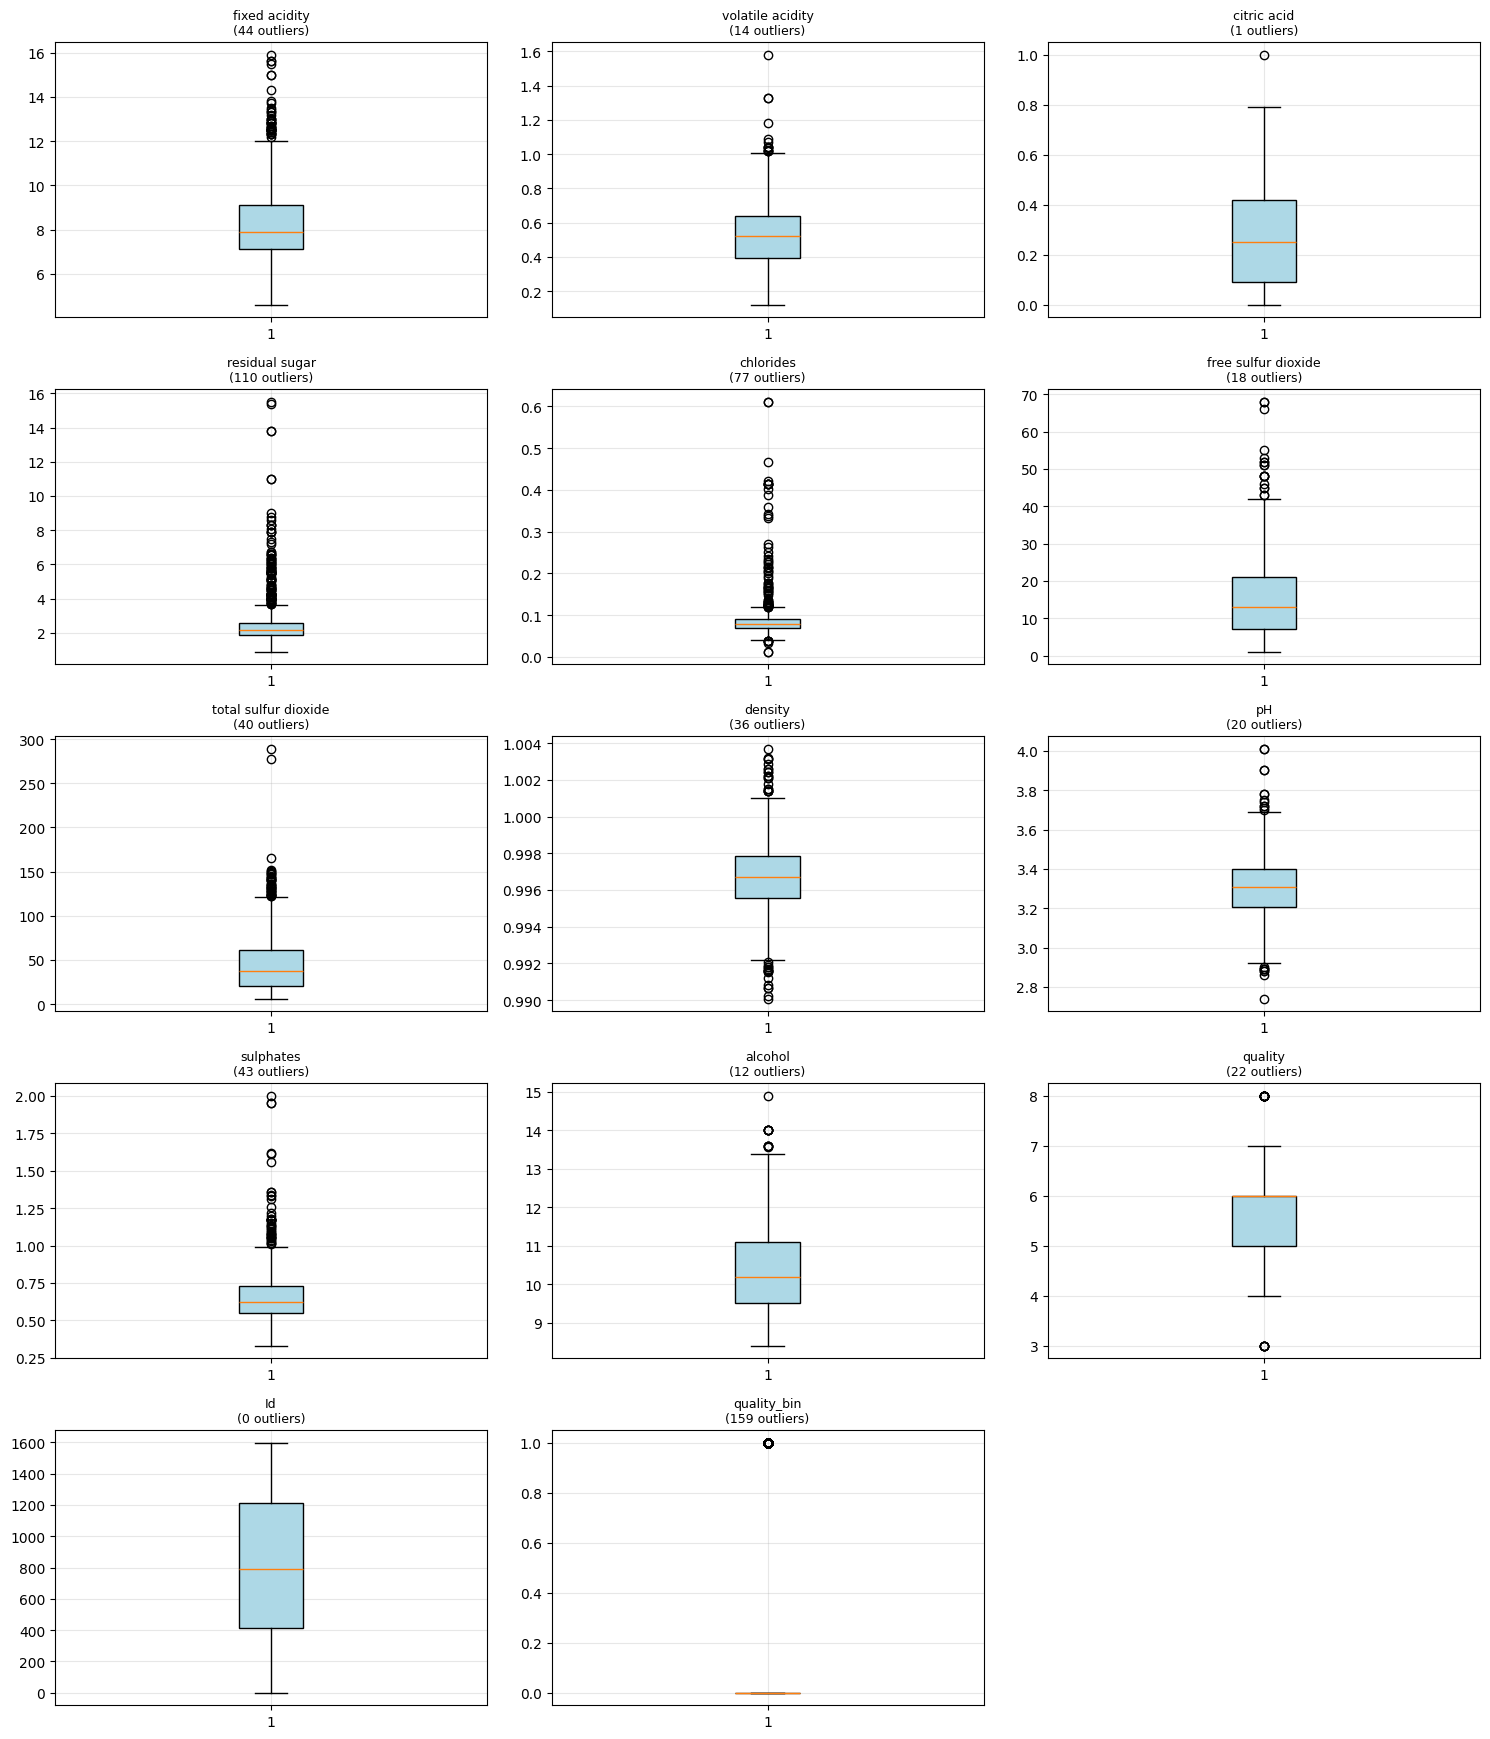


✅ Lignes avec au moins 1 outlier: 403 (35.26%)


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Colonnes numériques
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Détection des outliers avec IQR
outliers = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers[col] = ((df[col] < lower) | (df[col] > upper)).sum()

# Affichage résumé
print("RÉSUMÉ DES OUTLIERS")
print("="*55)
print(f"{'Colonne':<30} {'Outliers':>10} {'%':>8}")
print("-"*55)
for col, count in outliers.items():
    pct = (count / len(df)) * 100
    print(f"{col:<30} {count:>10} {pct:>7.2f}%")
print("="*55)

# Visualisation - Boxplots
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{col}\n({outliers[col]} outliers)', fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Cacher les axes vides
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Statistiques globales (CORRIGÉ)
outlier_matrix = pd.DataFrame()
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_matrix[col] = (df[col] < lower) | (df[col] > upper)

lignes_avec_outliers = outlier_matrix.any(axis=1).sum()
print(f"\n✅ Lignes avec au moins 1 outlier: {lignes_avec_outliers} ({lignes_avec_outliers/len(df)*100:.2f}%)")

avant de traiter les outliers je teste des models 

étude de corrélation

CORRÉLATION AVEC 'QUALITY'
quality                 1.000000
quality_bin             0.720433
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


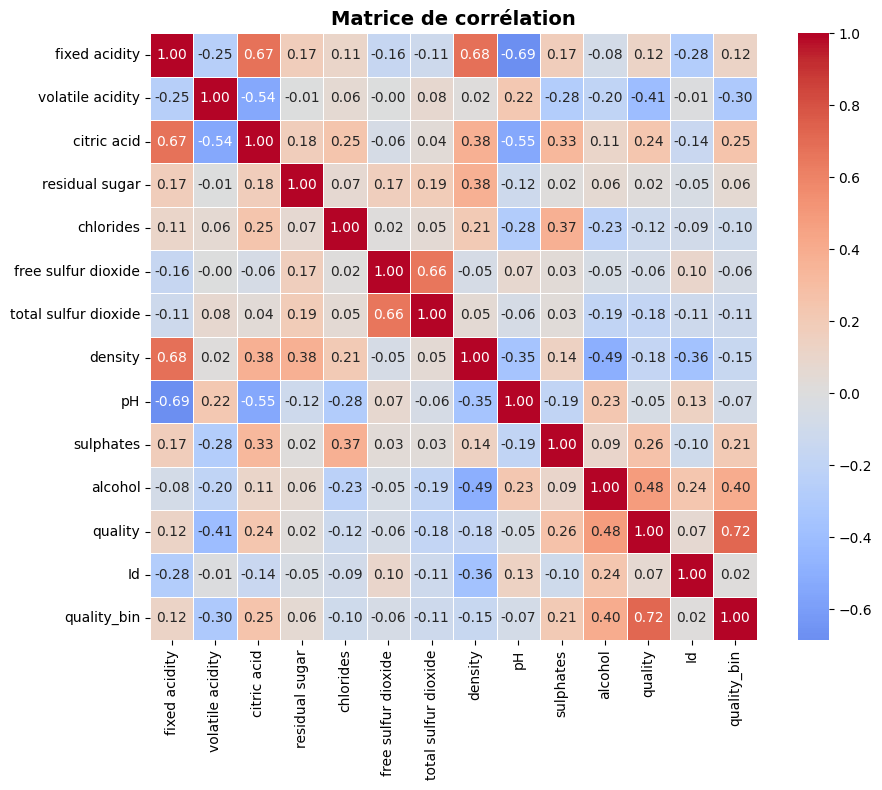


TOP VARIABLES (par corrélation absolue)
quality_bin                   : +0.7204 (valeur: 0.7204)
alcohol                       : +0.4849 (valeur: 0.4849)
volatile acidity              : -0.4074 (valeur: -0.4074)
sulphates                     : +0.2577 (valeur: 0.2577)
citric acid                   : +0.2408 (valeur: 0.2408)
total sulfur dioxide          : -0.1833 (valeur: -0.1833)
density                       : -0.1752 (valeur: -0.1752)
chlorides                     : -0.1241 (valeur: -0.1241)
fixed acidity                 : +0.1220 (valeur: 0.1220)
Id                            : +0.0697 (valeur: 0.0697)
free sulfur dioxide           : -0.0633 (valeur: -0.0633)
pH                            : -0.0525 (valeur: -0.0525)
residual sugar                : +0.0220 (valeur: 0.0220)


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========================================
# CORRÉLATIONS AVEC LA VARIABLE CIBLE
# ========================================

# Calculer les corrélations avec 'quality'
correlations = df.corr()['quality'].sort_values(ascending=False)

print("="*60)
print("CORRÉLATION AVEC 'QUALITY'")
print("="*60)
print(correlations)

# ========================================
# VISUALISATION - HEATMAP
# ========================================

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Matrice de corrélation', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# ========================================
# TOP VARIABLES LES PLUS CORRÉLÉES
# ========================================

print("\n" + "="*60)
print("TOP VARIABLES (par corrélation absolue)")
print("="*60)

# Exclure 'quality' elle-même
top_corr = correlations.drop('quality').abs().sort_values(ascending=False)

for col, corr_abs in top_corr.items():
    corr_value = correlations[col]
    sign = "+" if corr_value > 0 else "-"
    print(f"{col:<30}: {sign}{corr_abs:.4f} (valeur: {corr_value:.4f})")

passant au deuxieme approche avec traitement des outliers et ajout des features eng

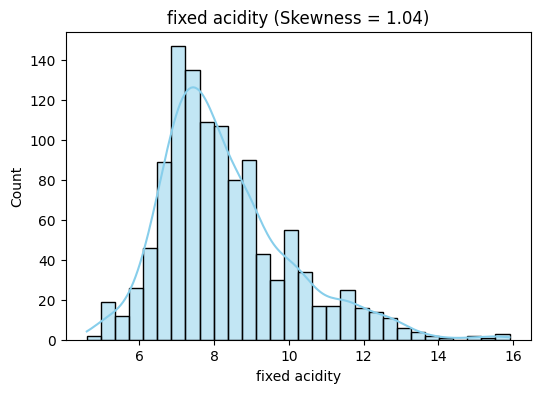

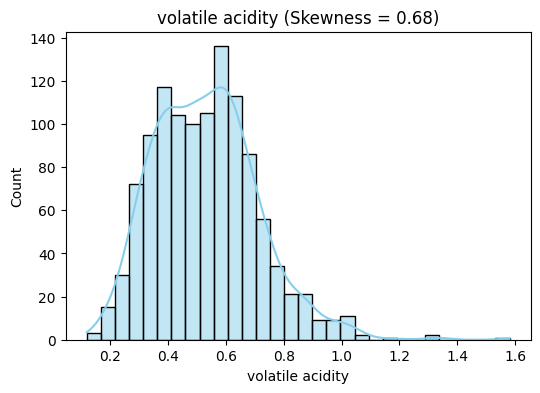

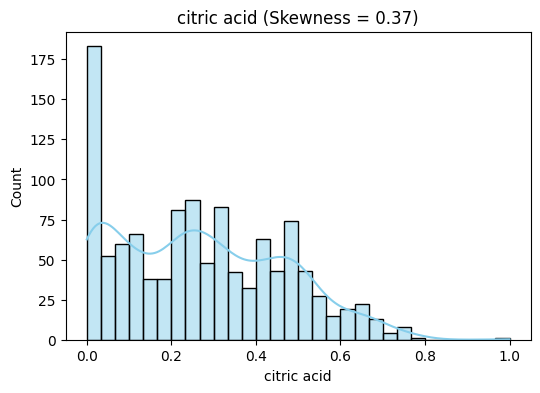

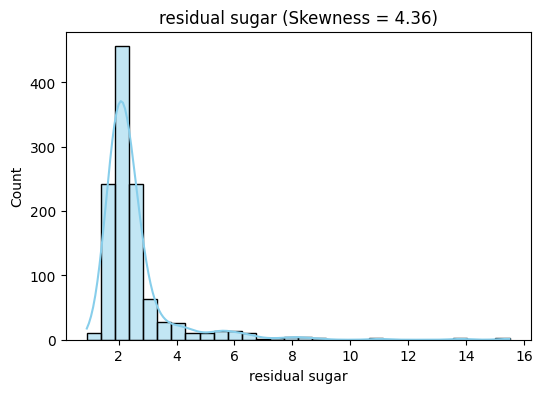

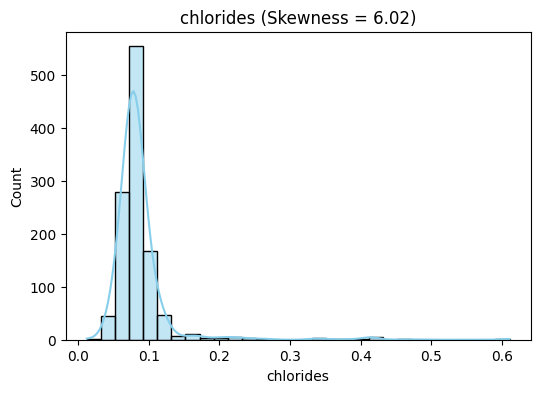

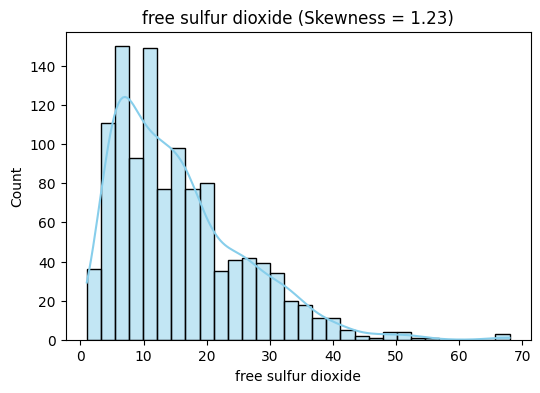

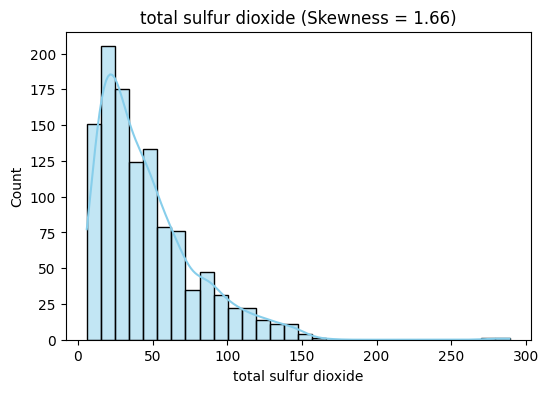

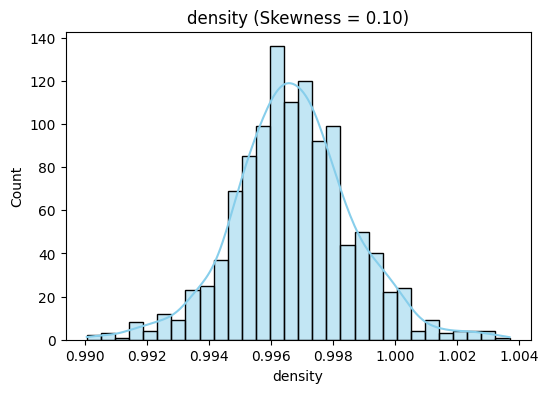

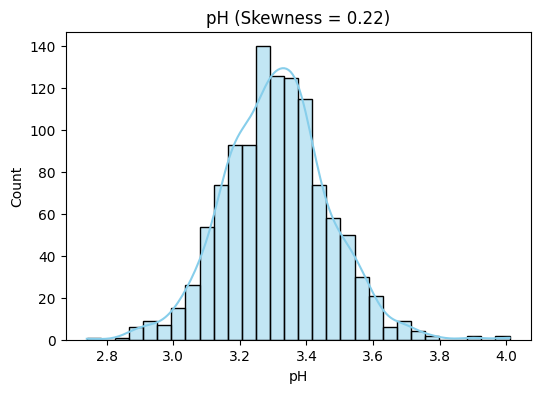

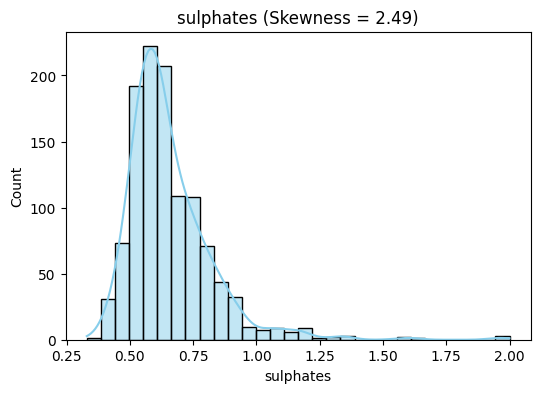

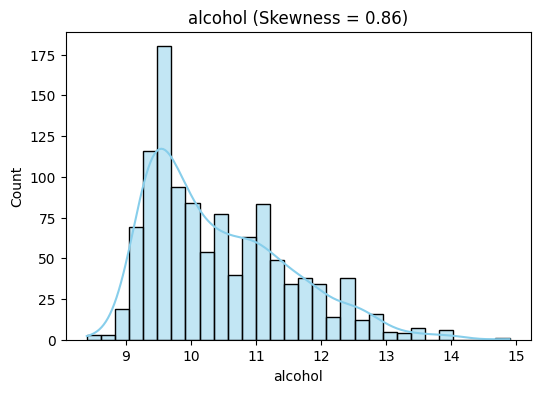

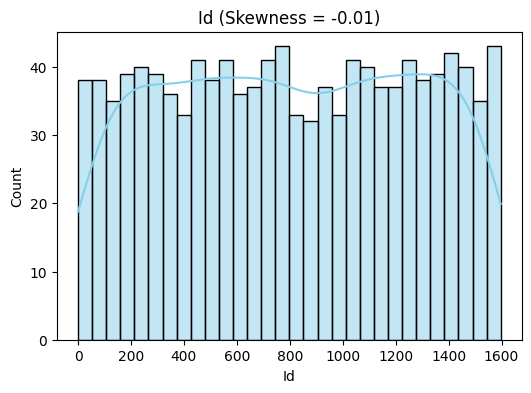

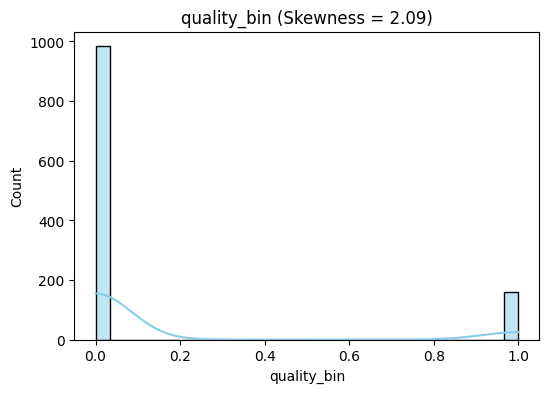

Skewness des features :
fixed acidity: 1.04
volatile acidity: 0.68
citric acid: 0.37
residual sugar: 4.36
chlorides: 6.02
free sulfur dioxide: 1.23
total sulfur dioxide: 1.66
density: 0.10
pH: 0.22
sulphates: 2.49
alcohol: 0.86
Id: -0.01
quality_bin: 2.09


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Colonnes numériques sauf la target
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('quality')  # on ne touche pas à la target

# Dictionnaire pour stocker le skewness
skew_values = {}

# Boucle sur chaque colonne
for col in num_cols:
    # Calcul skewness
    skew_val = skew(df[col])
    skew_values[col] = skew_val
    
    # Affichage histogramme + KDE
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} (Skewness = {skew_val:.2f})')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Afficher les valeurs de skewness
print("Skewness des features :")
for col, val in skew_values.items():
    print(f"{col}: {val:.2f}")


Règle simple pour la symétrie (skewness) et les outliers

Symétrique (skew ≈ 0) → la plupart des valeurs sont autour de la moyenne, les outliers peuvent être à gauche ou à droite.

Asymétrie à droite (skew > 0) → la majorité des valeurs est inférieure à la moyenne, les outliers sont au-dessus de la moyenne.

Asymétrie à gauche (skew < 0) → la majorité des valeurs est supérieure à la moyenne, les outliers sont en dessous de la moyenne.

traitement des outliers avec utilisation de Winsorization (technique qui permet de remplacer les outliers par les bornes)

In [30]:
import pandas as pd
import numpy as np

# Copier le dataset pour ne pas toucher à l'original
df_winsor = df.copy()

# Liste des features avec transformations
log_features = ['residual sugar', 'chlorides', 'total sulfur dioxide', 'sulphates']
sqrt_features = ['fixed acidity']  # optionnel, selon recommandation
winsor_features = ['volatile acidity', 'citric acid', 'free sulfur dioxide', 
                   'density', 'pH', 'alcohol', 'fixed acidity', 'residual sugar', 
                   'chlorides', 'total sulfur dioxide', 'sulphates']

# Appliquer transformation log1p
for col in log_features:
    df_winsor[col] = np.log1p(df_winsor[col])

# Appliquer transformation sqrt
for col in sqrt_features:
    df_winsor[col] = np.sqrt(df_winsor[col])

# Winsorization fonction
def winsorize_series(s, factor=1.5):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    s = s.clip(lower=lower, upper=upper)  # limite les valeurs
    return s

# Appliquer Winsorization sur toutes les features sélectionnées
for col in winsor_features:
    df_winsor[col] = winsorize_series(df_winsor[col])

# Vérification : afficher min et max après traitement
df_winsor[winsor_features].describe()


,volatile acidity,citric acid,free sulfur dioxide,density,pH,alcohol,fixed acidity,residual sugar,chlorides,total sulfur dioxide,sulphates
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,0.529884,0.268290,15.463255,0.996725,3.310105,10.437854,2.864568,1.191481,0.077724,3.624438,0.497574
std,0.174273,0.196425,9.725860,0.001843,0.151786,1.068643,0.283318,0.188161,0.016442,0.677570,0.082402
min,0.120000,0.000000,1.000000,0.992157,2.912500,8.400000,2.144761,0.740376,0.039880,1.945910,0.285179
25%,0.392500,0.090000,7.000000,0.995570,3.205000,9.500000,2.664583,1.064711,0.067659,3.091042,0.438255
50%,0.520000,0.250000,13.000000,0.996680,3.310000,10.200000,2.810694,1.163151,0.076035,3.637586,0.482426
75%,0.640000,0.420000,21.000000,0.997845,3.400000,11.100000,3.016621,1.280934,0.086178,4.127134,0.548121
max,1.011250,0.915000,42.000000,1.001257,3.692500,13.500000,3.544678,1.605269,0.113956,5.669881,0.712921


In [31]:
# Liste des colonnes numériques à vérifier
num_cols = df_winsor.select_dtypes(include=['float64', 'int64']).columns

# Dictionnaire pour stocker le nombre d'outliers restants
outliers_restants = {}

# Détection des outliers après Winsorization
for col in num_cols:
    Q1 = df_winsor[col].quantile(0.25)
    Q3 = df_winsor[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_restants[col] = df_winsor[(df_winsor[col] < lower) | (df_winsor[col] > upper)][col].count()

# Affichage des résultats
print("Nombre d'outliers restants par colonne après Winsorization :\n")
for col, count in outliers_restants.items():
    pct = (count / len(df_winsor)) * 100
    print(f"{col:<25} {count:>5} ({pct:.2f}%)")


Nombre d'outliers restants par colonne après Winsorization :

fixed acidity                 0 (0.00%)
volatile acidity              0 (0.00%)
citric acid                   0 (0.00%)
residual sugar                0 (0.00%)
chlorides                     0 (0.00%)
free sulfur dioxide           0 (0.00%)
total sulfur dioxide          0 (0.00%)
density                       0 (0.00%)
pH                            0 (0.00%)
sulphates                     0 (0.00%)
alcohol                       0 (0.00%)
quality                      22 (1.92%)
Id                            0 (0.00%)
quality_bin                 159 (13.91%)


l'ajout des feautures :

acid_sugar_ratio = fixed acidity / residual sugar → acidité relative au sucre
sulfur_ratio = free sulfur dioxide / total sulfur dioxide → proportion de SO2 libre
density_alcohol = density / alcohol → influence de la densité et alcool

acidity_score = fixed acidity + volatile acidity + citric acid → score global d’acidité
sulphates_alcohol = sulphates * alcohol → impact combiné sur goût et conservation

sugar_density = residual sugar * density
chlorides_sulphates = chlorides * sulphates

Corrélation de toutes les features avec la target (quality) :
quality                 1.000000
sulphates_alcohol       0.517359
density_alcohol        -0.489006
alcohol                 0.488844
alcohol_squared         0.485631
volatile acidity       -0.405475
sulphates               0.339045
citric acid             0.241920
chlorides              -0.184419
density                -0.177422
total sulfur dioxide   -0.171557
fixed acidity           0.116680
free sulfur dioxide    -0.061273
pH                     -0.056066
pH_squared             -0.056012
chlorides_sulphates     0.041887
acid_sugar_ratio        0.038930
residual sugar          0.034094
sugar_density           0.031863
acidity_score           0.024683
sulfur_ratio           -0.011729
Name: quality, dtype: float64


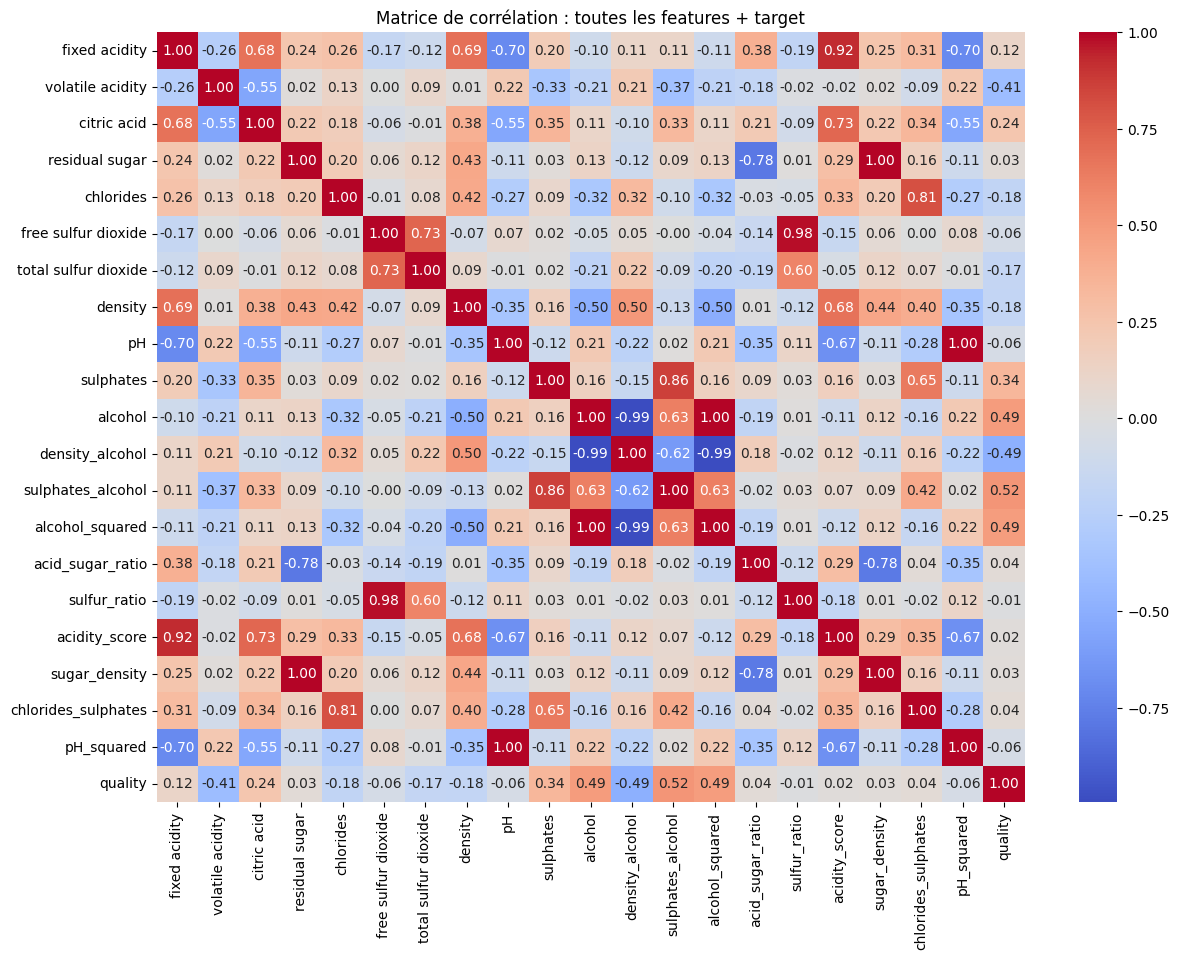

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copier df_winsor pour ne pas toucher l'original
df_feat = df_winsor.copy()

# 🔹 Création des nouvelles features importantes
df_feat['density_alcohol'] = df_feat['density'] / (df_feat['alcohol'] + 1e-6)
df_feat['sulphates_alcohol'] = df_feat['sulphates'] * df_feat['alcohol']
df_feat['alcohol_squared'] = df_feat['alcohol'] ** 2
df_feat['acid_sugar_ratio'] = df_feat['fixed acidity'] / (df_feat['residual sugar'] + 1e-6)
df_feat['sulfur_ratio'] = df_feat['free sulfur dioxide'] / (df_feat['total sulfur dioxide'] + 1e-6)
df_feat['acidity_score'] = df_feat['fixed acidity'] + df_feat['volatile acidity'] + df_feat['citric acid']
df_feat['sugar_density'] = df_feat['residual sugar'] * df_feat['density']
df_feat['chlorides_sulphates'] = df_feat['chlorides'] * df_feat['sulphates']
df_feat['pH_squared'] = df_feat['pH'] ** 2

# 🔹 Liste de toutes les features de base + nouvelles features
all_features = [
    'fixed acidity','volatile acidity','citric acid','residual sugar','chlorides',
    'free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol',
    'density_alcohol','sulphates_alcohol','alcohol_squared','acid_sugar_ratio',
    'sulfur_ratio','acidity_score','sugar_density','chlorides_sulphates','pH_squared'
]

# 🔹 Calcul de la corrélation avec la target
corr_target = df_feat[all_features + ['quality']].corr()['quality'].sort_values(key=abs, ascending=False)

print("Corrélation de toutes les features avec la target (quality) :")
print(corr_target)

# 🔹 Optionnel : matrice de corrélation complète pour visualisation
plt.figure(figsize=(14,10))
sns.heatmap(df_feat[all_features + ['quality']].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation : toutes les features + target")
plt.show()


On garde les features avec une corrélation absolue ≥ 0.1

eatures à garder :
sulphates_alcohol, density_alcohol, alcohol, alcohol_squared, volatile acidity, sulphates, citric acid, chlorides, density, total sulfur dioxide, fixed acidity

In [33]:
# Supprimer les doublons
df_feat = df_feat.drop_duplicates()

# Vérifier qu'il reste bien des lignes
print("Après suppression des doublons :", df_feat.shape[0])

# Features importantes
important_features = [
    'sulphates_alcohol', 'density_alcohol', 'alcohol', 'alcohol_squared',
    'volatile acidity', 'sulphates', 'citric acid', 'chlorides',
    'density', 'total sulfur dioxide', 'fixed acidity'
]

# Créer le DataFrame final
df_selected = df_feat[important_features + ['quality']]

print("Aperçu des données finales :")
print(df_selected.head())

# Vérifier doublons
print("Doublons restants :", df_selected.duplicated().sum())

# Sauvegarder CSV
csv_path = "wine_selected_features.csv"
df_selected.to_csv(csv_path, index=False)
print(f"CSV sauvegardé avec succès dans : {csv_path}")
print("Nombre de lignes :", df_selected.shape[0])


Après suppression des doublons : 1143
Aperçu des données finales :
   sulphates_alcohol  density_alcohol  alcohol  alcohol_squared  \
0           4.180047         0.106149      9.4            88.36   
1           5.084179         0.101714      9.8            96.04   
2           4.907598         0.101735      9.8            96.04   
3           4.482764         0.101837      9.8            96.04   
4           4.180047         0.106149      9.4            88.36   

   volatile acidity  sulphates  citric acid  chlorides  density  \
0              0.70   0.444686         0.00   0.073250   0.9978   
1              0.88   0.518794         0.00   0.093490   0.9968   
2              0.76   0.500775         0.04   0.088011   0.9970   
3              0.28   0.457425         0.56   0.072321   0.9980   
4              0.70   0.444686         0.00   0.073250   0.9978   

   total sulfur dioxide  fixed acidity  quality  
0              3.555348       2.720294        5  
1              4.219508    

test après les transformations

F1-macro est de donner le MÊME intérêt à TOUTES les classes

In [36]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# =============================================================================
# 1️⃣ LOAD DATA
# =============================================================================
df = pd.read_csv("wine_selected_features.csv")

# Binary target
# 0 = Mauvais / Moyen, 1 = Bon
df["quality_bin"] = (df["quality"] > 5).astype(int)

X = df.drop(columns=["quality", "quality_bin"])
y = df["quality_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Train={X_train.shape[0]} | Test={X_test.shape[0]}")
print(f"📊 Distribution Train:\n{y_train.value_counts(normalize=True)}")

# =============================================================================
# 2️⃣ CV STRATEGY
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =============================================================================
# 3️⃣ MODELS + GRIDS
# =============================================================================
models = {
    "LogisticRegression": {
        "pipe": Pipeline([
            ("scaler", RobustScaler()),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.1, 0.5, 1.0]
        }
    },

    "RandomForest": {
        "pipe": Pipeline([
            ("scaler", RobustScaler()),
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [6, 8],
            "model__min_samples_leaf": [10, 15],
            "model__max_features": ["sqrt"]
        }
    },

    "ExtraTrees": {
        "pipe": Pipeline([
            ("scaler", RobustScaler()),
            ("model", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__n_estimators": [300, 400],
            "model__max_depth": [6, 8],
            "model__min_samples_leaf": [10, 15],
            "model__max_features": ["sqrt"]
        }
    },

    "XGBoost": {
        "pipe": Pipeline([
            ("scaler", RobustScaler()),
            ("model", XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                tree_method="hist",
                scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [3, 4],
            "model__learning_rate": [0.03, 0.05],
            "model__subsample": [0.7, 0.8],
            "model__colsample_bytree": [0.7, 0.8]
        }
    },

    "LightGBM": {
        "pipe": Pipeline([
            ("scaler", RobustScaler()),
            ("model", LGBMClassifier(
                random_state=42,
                class_weight="balanced",
                verbose=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [3, 4],
            "model__learning_rate": [0.03, 0.05],
            "model__subsample": [0.7, 0.8],
            "model__colsample_bytree": [0.7, 0.8]
        }
    },

    "CatBoost": {
        "pipe": Pipeline([
            ("scaler", RobustScaler()),
            ("model", CatBoostClassifier(
                random_state=42,
                loss_function="Logloss",
                verbose=0
            ))
        ]),
        "params": {
            "model__iterations": [300, 400],
            "model__depth": [4, 5],
            "model__learning_rate": [0.03, 0.05]
        }
    }
}

# =============================================================================
# 4️⃣ TRAIN + OVERFITTING CHECK (F1) + BEST PARAMS 🔥
# =============================================================================
results = []

for name, cfg in models.items():
    print(f"\n{'='*70}")
    print(f"🔹 {name}")
    print(f"{'='*70}")

    grid = GridSearchCV(
        cfg["pipe"],
        cfg["params"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best = grid.best_estimator_

    y_train_pred = best.predict(X_train)
    y_test_pred = best.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test  = f1_score(y_test, y_test_pred, average='macro')

    f1_cv = grid.best_score_

    overfit = f1_train - f1_test

    # 🔥 AJOUT : AFFICHAGE DES MEILLEURS HYPERPARAMÈTRES
    print(f"🔥 BEST PARAMS: {grid.best_params_}")

    results.append({
        "Model": name,
        "Train F1": f1_train,
        "CV F1": f1_cv,
        "Test F1": f1_test,
        "Overfit": overfit,
        "Pipeline": best
    })

    status = "✅ Good" if abs(overfit) < 0.05 else "⚠️ Overfitting"

    print(f"Train F1 : {f1_train:.4f}")
    print(f"CV F1    : {f1_cv:.4f}")
    print(f"Test F1  : {f1_test:.4f}")
    print(f"Overfit  : {overfit:.4f} {status}")

# =============================================================================
# 5️⃣ FINAL COMPARISON
# =============================================================================
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("Test F1", ascending=False)

print("\n🏆 FINAL RANKING (Binary Classification)")
print(df_results[["Model", "Train F1", "CV F1", "Test F1", "Overfit"]])

best_model = df_results.iloc[0]["Pipeline"]
best_name = df_results.iloc[0]["Model"]

# =============================================================================
# 6️⃣ BEST MODEL REPORT
# =============================================================================
print(f"\n🥇 BEST MODEL : {best_name}")

y_pred = best_model.predict(X_test)

print("\n📋 Classification Report")
print(classification_report(y_test, y_pred))

print("\n📊 Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\n✅ BINARY PIPELINE FINISHED SUCCESSFULLY")


✅ Train=914 | Test=229
📊 Distribution Train:
quality_bin
1    0.543764
0    0.456236
Name: proportion, dtype: float64

🔹 LogisticRegression
🔥 BEST PARAMS: {'model__C': 1.0}
Train F1 : 0.7469
CV F1    : 0.7431
Test F1  : 0.7641
Overfit  : -0.0171 ✅ Good

🔹 RandomForest
🔥 BEST PARAMS: {'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 15, 'model__n_estimators': 200}
Train F1 : 0.8203
CV F1    : 0.7637
Test F1  : 0.7726
Overfit  : 0.0478 ✅ Good

🔹 ExtraTrees
🔥 BEST PARAMS: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
Train F1 : 0.7862
CV F1    : 0.7552
Test F1  : 0.7636
Overfit  : 0.0226 ✅ Good

🔹 XGBoost
🔥 BEST PARAMS: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.7}
Train F1 : 0.9242
CV F1    : 0.7695
Test F1  : 0.7883
Overfit  : 0.1359 ⚠️ Overfitting

🔹 LightGBM
🔥 BEST PARAMS: {'model__colsample_byt

autres techniques pour améliorer performances

Voting Classifier : 3 meilleurs modèles non-overfitting (LogisticRegression, RandomForest, ExtraTrees)

In [49]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# =============================================================================
# 1️⃣ LOAD DATA
# =============================================================================
df = pd.read_csv("wine_selected_features.csv")
df["quality_bin"] = (df["quality"] > 5).astype(int)
X = df.drop(columns=["quality", "quality_bin"])
y = df["quality_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train={X_train.shape[0]} | Test={X_test.shape[0]}")
print(f"📊 Distribution Train:\n{y_train.value_counts(normalize=True)}")

# =============================================================================
# 2️⃣ 3 MODÈLES AVEC LEURS BEST PARAMS EXACTS
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 🔥 LogisticRegression BEST PARAMS: {'model__C': 1.0}
logreg = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        C=1.0,  # BEST PARAM
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# 🔥 RandomForest BEST PARAMS
rf = Pipeline([
    ("scaler", RobustScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,      # BEST PARAM
        max_depth=6,           # BEST PARAM  
        min_samples_leaf=15,   # BEST PARAM
        max_features='sqrt',   # BEST PARAM
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

# 🔥 ExtraTrees BEST PARAMS  
et = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ExtraTreesClassifier(
        n_estimators=300,      # BEST PARAM
        max_depth=8,           # BEST PARAM
        min_samples_leaf=10,   # BEST PARAM
        max_features='sqrt',   # BEST PARAM
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

# 🔥 VOTING CLASSIFIER (SOFT = MEILLEUR)
voting_clf = VotingClassifier([
    ('logreg', logreg),
    ('rf', rf),
    ('et', et)
], voting='soft', n_jobs=-1)  # soft voting = moyenne probabilités

# =============================================================================
# 3️⃣ ÉVALUATION F1 MACRO
# =============================================================================
print(f"\n{'='*80}")
print(f"🔥 VOTING ENSEMBLE - 3 MODÈLES SANS OVERFITTING")
print(f"{'='*80}")

voting_clf.fit(X_train, y_train)

# Predictions
y_train_pred = voting_clf.predict(X_train)
y_test_pred = voting_clf.predict(X_test)

# F1 Macro scores
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_test = f1_score(y_test, y_test_pred, average='macro')

# CV F1 Macro
f1_cv_scores = cross_val_score(voting_clf, X_train, y_train, 
                              scoring='f1_macro', cv=cv, n_jobs=-1)
f1_cv = f1_cv_scores.mean()

overfit = f1_train - f1_test

print(f" Train F1 : {f1_train:.4f}")
print(f" CV F1    : {f1_cv:.4f}")
print(f" Test F1  : {f1_test:.4f}")
print(f" Overfit  : {overfit:.4f}", "✅ Good" if abs(overfit) < 0.05 else "⚠️ Overfitting")

# =============================================================================
# 4️⃣ COMPARAISON
# =============================================================================
print(f"\n{'='*80}")
print(f" COMPARAISON F1 MACRO")
print(f"{'='*80}")
comparison = pd.DataFrame({
    'Model': ['Voting_Ensemble', 'CatBoost', 'RandomForest', 'LogisticRegression', 'ExtraTrees'],
    'Test_F1_macro': [f1_test, 0.8013, 0.7726, 0.7641, 0.7636]
})
print(comparison.sort_values('Test_F1_macro', ascending=False).round(4))

# =============================================================================
# 5️⃣ DÉTAILED REPORT
# =============================================================================
print(f"\n Classification Report (Voting)")
print(classification_report(y_test, y_test_pred))

print("\n Confusion Matrix (Voting)")
print(confusion_matrix(y_test, y_test_pred))

print(f"\n VOTING ENSEMBLE TERMINÉ")
print(f" F1 Macro : {f1_test:.4f}")


✅ Train=914 | Test=229
📊 Distribution Train:
quality_bin
1    0.543764
0    0.456236
Name: proportion, dtype: float64

🔥 VOTING ENSEMBLE - 3 MODÈLES SANS OVERFITTING
 Train F1 : 0.7787
 CV F1    : 0.7553
 Test F1  : 0.7856
 Overfit  : -0.0069 ✅ Good

 COMPARAISON F1 MACRO
                Model  Test_F1_macro
1            CatBoost         0.8013
0     Voting_Ensemble         0.7856
2        RandomForest         0.7726
3  LogisticRegression         0.7641
4          ExtraTrees         0.7636

 Classification Report (Voting)
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       105
           1       0.83      0.77      0.79       124

    accuracy                           0.79       229
   macro avg       0.79      0.79      0.79       229
weighted avg       0.79      0.79      0.79       229


 Confusion Matrix (Voting)
[[85 20]
 [29 95]]

 VOTING ENSEMBLE TERMINÉ
 F1 Macro : 0.7856


alors par utilisation de F1_macro la performance augmente a F1 Macro : 0.7856

bugging

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
import warnings
warnings.filterwarnings("ignore")

# ======================
# 1️ LOAD DATA
# ======================
df = pd.read_csv("wine_selected_features.csv")

# Binary target: 0 = Mauvais/Moyen, 1 = Bon
df["quality_bin"] = (df["quality"] > 5).astype(int)

X = df.drop(columns=["quality", "quality_bin"])
y = df["quality_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Train={X_train.shape[0]} | Test={X_test.shape[0]}")
print(f" Distribution Train:\n{y_train.value_counts(normalize=True)}")

# ======================
# 2️ CROSS-VALIDATION STRATEGY
# ======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ======================
# 3️ Bagging RandomForest
# ======================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=10,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('model', BaggingClassifier(
        estimator=rf,
        n_estimators=10,       # Combien de RF à entraîner
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

# ======================
# 4️ Cross-validation pour F1 macro
# ======================
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
f1_cv = cv_scores.mean()

# ======================
# 5️ Entraînement
# ======================
pipe.fit(X_train, y_train)

y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_test = f1_score(y_test, y_test_pred, average='macro')
overfit = f1_train - f1_test

# ======================
# 6️ Affichage
# ======================
status = "✅ Good" if abs(overfit) < 0.05 else "⚠️ Overfitting" if abs(overfit) < 0.1 else "❌ Strong Overfitting"

print("\n🏆 Bagging RandomForest - Performance")
print("-"*50)
print(f"Train F1 : {f1_train:.4f}")
print(f"CV F1    : {f1_cv:.4f}")
print(f"Test F1  : {f1_test:.4f}")
print(f"Overfit  : {overfit:.4f} {status}")

print("\n Classification Report")
print(classification_report(y_test, y_test_pred))

print("\n Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred))


 Train=914 | Test=229
 Distribution Train:
quality_bin
1    0.543764
0    0.456236
Name: proportion, dtype: float64

🏆 Bagging RandomForest - Performance
--------------------------------------------------
Train F1 : 0.8068
CV F1    : 0.7509
Test F1  : 0.7752
Overfit  : 0.0316 ✅ Good

 Classification Report
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       105
           1       0.79      0.81      0.80       124

    accuracy                           0.78       229
   macro avg       0.78      0.77      0.78       229
weighted avg       0.78      0.78      0.78       229


 Confusion Matrix
[[ 78  27]
 [ 24 100]]


apés utilisation du bugging f1_macro test = 0.78

l'utilisation du stacking

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import joblib

# ======================
# 1️ Charger les données
# =====================
df = pd.read_csv("wine_selected_features.csv")
df["quality_bin"] = (df["quality"] > 5).astype(int)
X = df.drop(columns=["quality", "quality_bin"])
y = df["quality_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Train={X_train.shape[0]} | Test={X_test.shape[0]}")
print(f" Distribution Train:\n{y_train.value_counts(normalize=True)}")

# ======================
# 2️ Modèles de base avec hyperparamètres optimaux
# ======================
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=15,
        max_features='sqrt', random_state=42, class_weight="balanced"
    )),
    ('et', ExtraTreesClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=15,
        max_features='sqrt', random_state=42, class_weight="balanced"
    )),
    ('xgb', XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        random_state=42, eval_metric='logloss'
    ))
]

# Métamodèle (final estimator)
meta_model = LogisticRegression(
    C=1.0, max_iter=2000, class_weight="balanced", random_state=42
)

# ======================
# 3️ StackingClassifier
# ======================
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=True  # inclut les features originales dans le métamodèle
)

# Pipeline avec normalisation
pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('stack', stack_model)
])

# ======================
# 4️ Entraînement
# ======================
pipe.fit(X_train, y_train)

# ======================
# 5️ Évaluation
# ======================
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_test  = f1_score(y_test, y_test_pred, average='macro')
overfit = f1_train - f1_test

print(f"Train F1 (macro): {f1_train:.4f}")
print(f"Test F1  (macro): {f1_test:.4f}")
print(f"Overfit        : {overfit:.4f}")
print("Classification Report :\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_test_pred))

# ======================
# 6️ Sauvegarder le modèle pour Streamlit
# ======================
joblib.dump(pipe, "Stacking_wine_model.pkl")
print(" Modèle Stacking sauvegardé : Stacking_wine_model.pkl")


 Train=914 | Test=229
 Distribution Train:
quality_bin
1    0.543764
0    0.456236
Name: proportion, dtype: float64
Train F1 (macro): 0.8203
Test F1  (macro): 0.8076
Overfit        : 0.0128
Classification Report :
               precision    recall  f1-score   support

           0       0.77      0.84      0.80       105
           1       0.85      0.78      0.82       124

    accuracy                           0.81       229
   macro avg       0.81      0.81      0.81       229
weighted avg       0.81      0.81      0.81       229

Confusion Matrix :
 [[88 17]
 [27 97]]
 Modèle Stacking sauvegardé : Stacking_wine_model.pkl


alors il donne f1_macro=0.81